## Setting Up Environment

In [4]:
# Install required packages
%pip install ipywidgets
%pip install torch transformers scikit-learn pandas matplotlib seaborn tqdm
%pip install optuna


# Standard libraries
import os, re, json, pickle, warnings
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# Transformers
from transformers import BertTokenizer, BertModel, BertForSequenceClassification

# ML utilities
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix, roc_curve, auc
)

# Progress bars
from tqdm import tqdm

# Suppress warnings
warnings.filterwarnings("ignore", category=FutureWarning)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 03/11/26

## Step 1: Data Collection & Preprocessing (MovieWorkflowManager)

This class acts as the data pipeline by...


* Reading CSV files of movie reviews (audience and critic) from multiple folders, each scraped from a platform (Rotten Tomatoes, IMDB, and Metacritic).

* Loading movie metadata (budget, gross US revenue, release year) for each movie.

* Normalizing ratings across platforms into a 0–1 scale. This is necessary because Rotten Tomatoes audience scores use a 0–5 star scale, critics use 0–10 or 0–100%, and IMDB uses 0–10.

* Filtering out any movies that couldn't be matched to financial data

* Creating the prediction label: a binary flag where 1 = hit means the movie earned at least 3× its budget in gross US revenue.

The final dataset covers 199 unique movies with ~18,000 individual reviews.
</p>

#### MovieWorkflowManager Structure

In [ ]:
class MovieWorkflowManager:
    """
    Orchestrates the full data pipeline for the movie box office prediction project.

    Responsibilities:
        - Locating and loading raw review and metadata CSV files from disk
        - Cleaning and normalising financial values and review scores
        - Merging reviews with financial metadata
        - Generating binary hit/flop labels based on ROI
        - Producing EDA visualisations
        - Splitting the dataset into two experimental trial structures

    Attributes:
        base_path (str): Root directory from which all data folders are resolved
                         (defaults to the current working directory).
        folders (dict): Maps each data-folder name to its review type ("audience"
                        or "critic") and source platform ("rt" or "imdb").
        stats (dict): Running counters updated during extraction:
                        - "scraped_files"    : total review CSV files encountered
                        - "dropped_no_finance": files skipped due to missing metadata
                        - "final_movies"     : unique movies present in the final dataset
    """

    def __init__(self):
        """
        Initialises the manager with the working directory as the base path,
        defines the expected data-folder layout, and zeroes the stats counters.
        """
        self.base_path = os.getcwd()
        self.folders = {
            "audience-reviews-rt":      {"type": "audience", "platform": "rt"},
            "audience-reviews-imdb": {"type": "audience", "platform": "imdb"},
            "critic-reviews-rt":     {"type": "critic",   "platform": "rt"}
            # "critic-reviews-metacritic": {"type": "critic", "platform": "metacritic"}
        }
        self.stats = {"scraped_files": 0, 
                      "dropped_no_finance": 0, 
                      "final_movies": 0,
                      "dropped_movies": 0}

    # ─────────────────────────────────────────────────────────────────────────
    # HELPER UTILITIES
    # ─────────────────────────────────────────────────────────────────────────

    def clean_val(self, v):
        """
        Strips non-numeric characters from a raw financial string and converts
        the result to a float.

        Handles currency symbols, commas, and whitespace (e.g. "$120,000,000"
        becomes 120000000.0). Returns np.nan for missing, null, or
        non-parseable values.

        Args:
            v (any): The raw value to clean — typically a string from a CSV cell,
                     but may be NaN or any other type.

        Returns:
            float | np.nan: The numeric value, or np.nan if the input could not
                            be converted.
        """
        if pd.isna(v) or v == "N/A":
            return np.nan
        s = re.sub(r'[^\d.]', '', str(v))
        return float(s) if s else np.nan

    def slugify(self, filename):
        """
        Derives a normalised, platform-agnostic movie key from a raw filename.

        Strips the file extension, lowercases the result, and removes common
        suffixes/prefixes introduced by the scraper (e.g. "_reviews", "_imdb",
        "_rt"). The resulting key is used to join review files with their
        corresponding metadata records.

        Example:
            "the_dark_knight_reviews_rt.csv"  →  "the_dark_knight"
            "inception_audience_imdb.csv"     →  "inception"

        Args:
            filename (str): The raw filename (with or without a directory path).

        Returns:
            str: A stripped, lowercase movie key suitable for dictionary lookups
                 and DataFrame joins.
        """
        name = os.path.splitext(filename)[0].lower()
        for term in ["reviews", "imdb", "rt", "roger", "ebert", "metadata", "audience", "critic"]:
            name = name.replace(term, "")
        return name.strip("_")

    def standardize_score(self, val, platform):
        """
        Normalises a raw review score to a consistent [0, 1] float regardless
        of the source platform's native rating scale.

        Each platform uses a different scale, so the conversion logic is
        platform-specific:

            - IMDB   : native scale is 0–10  →  divided by 10
            - RT     : three possible scales detected heuristically:
                          score > 10  →  percentage (0–100), divided by 100
                          score ≤ 5   →  star rating (0–5),  divided by 5
                          otherwise   →  0–10 scale,         divided by 10

        Args:
            val (any): The raw score value from the CSV — may be a string such
                       as "4/5", "8.5/10", or "80%", a plain number, or NaN.
            platform (str): The source platform identifier; currently supports
                            "imdb" and "rt".

        Returns:
            float | np.nan: A normalised score in [0, 1], or np.nan if the
                            value could not be parsed.
        """
        if pd.isna(val) or val == "":
            return np.nan

        # Strip fraction denominators and percentage signs (e.g. "4/5" → "4", "80%" → "80")
        val_str = str(val).split('/')[0].replace('%', '').strip()
        try:
            score = float(val_str)
        except ValueError:
            return np.nan

        if platform == "imdb":
            return score / 10.0

        if platform == "rt":
            if score > 10:
                return score / 100.0
            if score <= 5:
                return score / 5.0
            return score / 10.0

        return score  # Fallback for unknown platforms

    # ─────────────────────────────────────────────────────────────────────────
    # DATA LOADING
    # ─────────────────────────────────────────────────────────────────────────

    def load_master_metadata(self, debug_output_path="master_metadata_ movies_with_complete_financial.csv"):

        """
        Builds a single, deduplicated metadata table by reading every
        "*metadata*.csv" file found across all configured data folders.

        Each metadata file is expected to contain at minimum:
            - A movie identifier column (named "movie_key" or the first column)
            - "budget"   : production budget (raw string, e.g. "$120,000,000")
            - "gross_us" : US box-office gross (raw string)
            - "year"     : release year

        Processing steps:
            1. Discover all metadata CSVs across configured folders.
            2. Normalise column names to lowercase.
            3. Generate a clean movie key via slugify().
            4. Concatenate all metadata frames and deduplicate on the clean key.
            5. Parse "budget" and "gross_us" with clean_val().
            6. Drop rows where either financial field is missing.
            7. Index the final table by the clean movie key for O(1) lookups.

        Returns:
            pd.DataFrame: A DataFrame indexed by normalised movie key with
                          columns ["budget", "gross", "year"]. Only movies with
                          valid budget AND gross values are included.
        """
        meta_list = []
        for folder in self.folders.keys():
            path = os.path.join(self.base_path, folder)
            if not os.path.exists(path): continue
            meta_files = [f for f in os.listdir(path) if "metadata" in f.lower() and f.endswith(".csv")]
            for mf in meta_files:
                temp_df = pd.read_csv(os.path.join(path, mf))
                temp_df.columns = [c.lower().strip() for c in temp_df.columns]
                key_col = 'movie_key' if 'movie_key' in temp_df.columns else temp_df.columns[0]
                temp_df['movie_key_clean'] = temp_df[key_col].apply(self.slugify)
                meta_list.append(temp_df[['movie_key_clean', 'budget', 'gross_us', 'year']])
        
        master = pd.concat(meta_list).drop_duplicates(subset=['movie_key_clean'])
        master['budget'] = master['budget'].apply(self.clean_val)
        master['gross'] = master['gross_us'].apply(self.clean_val)
        result = master.dropna(subset=['budget', 'gross']).set_index('movie_key_clean')

        # Save debug CSV with the slugified keys so you can compare against review filenames
        if debug_output_path:
            result.reset_index()[['movie_key_clean', 'budget', 'gross', 'year']].to_csv(debug_output_path, index=False)
            print(f"[debug] Master metadata saved to: {debug_output_path}")

        return result

    # ─────────────────────────────────────────────────────────────────────────
    # FULL PIPELINE
    # ─────────────────────────────────────────────────────────────────────────

    def run_full_extraction(self):
        """
        Executes the complete data-extraction pipeline, producing a single,
        model-ready DataFrame that combines reviews with financial metadata.

        Steps performed:
            1. Load the master metadata table via load_master_metadata().
            2. Iterate over every non-metadata review CSV in each configured folder.
            3. Slugify the filename to obtain the movie key.
            4. Skip (and count) any file whose movie key is absent from the
               metadata index (no financial data available).
            5. For matched files:
                a. Detect which column holds the raw rating score.
                b. Normalise the score to [0, 1] via standardize_score().
                c. Attach metadata columns: movie_title, budget, gross, year,
                   and is_critic (1 for critic reviews, 0 for audience).
            6. Concatenate all per-movie DataFrames.
            7. Compute the binary prediction label:
                   label = 1  if  gross / budget >= 3.0  (hit)
                   label = 0  otherwise                   (flop)
            8. Update self.stats with final movie count.

        Updates:
            self.stats["scraped_files"]      incremented per review file found
            self.stats["dropped_no_finance"] incremented per file skipped
            self.stats["final_movies"]       set to the number of unique movies

        Returns:
            pd.DataFrame: One row per individual review, with columns including
                          at minimum: review_text, user_rating, movie_title,
                          budget, gross, year, is_critic, label.
        """
        master_meta = self.load_master_metadata()
        all_data = []

        for folder, info in self.folders.items():
            path = os.path.join(self.base_path, folder)
            if not os.path.exists(path):
                continue
            files = [f for f in os.listdir(path)
                     if f.endswith(".csv") and "metadata" not in f.lower()]

            for f in files:
                self.stats["scraped_files"] += 1
                key = self.slugify(f)

                if key in master_meta.index:
                    m = master_meta.loc[key]
                    rdf = pd.read_csv(os.path.join(path, f))
                    rdf.columns = [c.lower().strip() for c in rdf.columns]

                    # Detect whichever rating column the scraper produced
                    score_col = None
                    for col in ['user_rating', 'score', 'rating', 'stars', 'user rating']:
                        if col in rdf.columns:
                            score_col = col
                            break

                    if score_col:
                        rdf['user_rating'] = rdf[score_col].apply(
                            lambda x: self.standardize_score(x, info['platform'])
                        )
                    else:
                        rdf['user_rating'] = np.nan

                    # Attach financial and categorical metadata to every review row
                    rdf['movie_title'] = key
                    rdf['budget']      = m['budget']
                    rdf['gross']       = m['gross']
                    rdf['year']        = m['year']
                    rdf['is_critic']   = 1 if info['type'] == "critic" else 0
                    all_data.append(rdf)
                else:
                    self.stats["dropped_no_finance"] += 1

        full_df = pd.concat(all_data, ignore_index=True)

        # Binary label: 1 = commercial hit (≥3× ROI), 0 = flop
        full_df['label'] = (full_df['gross'] / full_df['budget'] >= 3.0).astype(int)
        self.stats["final_movies"] = full_df['movie_title'].nunique()
        return full_df

    # ─────────────────────────────────────────────────────────────────────────
    # EDA
    # ─────────────────────────────────────────────────────────────────────────

    def run_eda_visuals(self, df):
        """
        Prints a data-survival summary and renders two exploratory visualisations.

        Visualisation 1 — Data Survival Bar Chart:
            Compares the total number of review files scraped against the number
            of movies that survived after filtering for financial data. Useful for
            understanding how much data was lost during the metadata join.

        Visualisation 2 — Audience vs. Critic Scatter Plot:
            For each movie that has both an audience and a critic rating, plots
            the average audience score (x-axis) against the average critic score
            (y-axis) with a linear regression line. Also prints the Pearson
            correlation coefficient between the two.

            If only one reviewer type is present in the data (e.g. no critic
            reviews were loaded), a warning is printed instead of the plot.

        Args:
            df (pd.DataFrame): The full extracted dataset returned by
                               run_full_extraction(). Must contain columns:
                               "user_rating", "is_critic", "movie_title".

        Returns:
            None. Outputs are printed to stdout and rendered via matplotlib.
        """        

        print("\n" + "=" * 30)
        print(" EXPLORATORY DATA ANALYSIS ")
        print("=" * 30)
        print(f"Total Review Files Scraped: {self.stats['scraped_files']}")
        print(f"Files dropped (no budget info): {self.stats['dropped_no_finance']}")
        print(f"Final Unique Movies in Study: {self.stats['final_movies']}")

        # --- Plot 1: Data Survival Bar Chart ---
        # Shows how many files were scraped vs. how many survived after filtering 
        # for financial data.

        plt.figure(figsize=(8, 4))
        sns.barplot(
            x=['Scraped', 'Valid (Financials)'],
            y=[self.stats['scraped_files'], self.stats['final_movies']],
            palette="mako"
        )
        plt.title("Workflow Step: Data Survival Comparison")
        plt.ylabel("Count of Movies")
        plt.show()

        plt.figure(figsize=(8, 4))
        sns.barplot(
            x=['Scraped', 'Valid (Financials)'],
            y=[self.stats['scraped_files'], self.stats['final_movies']],
            palette="mako"
        )
        plt.title("Workflow Step: Data Survival Comparison")
        plt.ylabel("Count of Files")
        plt.show()

        # --- Plot 2: Audience vs. Critic Correlatio Plot ---
        # Plots average audience rating against average critic rating per movie.
        # The correlation coefficient came out at 0.008, meaning audiences and critics 
        # barely agree.
        temp_df = df.dropna(subset=['user_rating']).copy()
        corr_data = temp_df.groupby(['movie_title', 'is_critic'])['user_rating'].mean().unstack()

        if corr_data.shape[1] >= 2:
            corr_plot_data = corr_data.dropna(subset=[0, 1])
            if not corr_plot_data.empty:
                x = corr_plot_data[0]   # audience ratings
                y = corr_plot_data[1]   # critic ratings

                plt.figure(figsize=(7,7))
                sns.regplot(
                    x=x,
                    y=y,
                    scatter_kws={'alpha':0.5,'color':'teal'},
                    line_kws={'color':'red'}
                )

                plt.xlabel("Average Audience Rating")
                plt.ylabel("Average Critic Rating")
                plt.title("Psychological Alignment: Audience vs. Critic")
                plt.grid(True, alpha=0.3)
                plt.show()

                # correlation
                r_val = x.corr(y)

                # regression stats
                slope, intercept, r_value, p_value, std_err = linregress(x, y)

                print("\n===== Statistical Insights =====")

                print(f"Movies used in analysis: {len(corr_plot_data)}")

                print(f"\nSentiment Correlation Coefficient (Audience vs Critic): {r_val:.3f}")

                print("\nRegression Line (Red Line)")
                print(f"Critic Rating ≈ {slope:.3f} * Audience Rating + {intercept:.3f}")

                print(f"\nSlope Interpretation:")
                print(f"For every +1 increase in audience rating, critic rating changes by {slope:.3f}")

                print(f"\nR² (Variance Explained): {r_value**2:.3f}")

                print(f"P-value (relationship significance): {p_value:.5f}")

                print(f"\nAverage Audience Rating: {x.mean():.2f}")
                print(f"Average Critic Rating: {y.mean():.2f}")

                print(f"\nAudience Rating Std Dev: {x.std():.2f}")
                print(f"Critic Rating Std Dev: {y.std():.2f}")

                print("\nHighest Agreement Movie:")
                diff = abs(x-y)
                best = diff.idxmin()
                print(best)

                print("\nLargest Critic vs Audience Disagreement:")
                worst = diff.idxmax()
                print(worst)
            else:
                print("Warning: No movies have both Audience AND Critic ratings. Check your data folders.")
        else:
            print(f"Warning: Only one 'is_critic' type found. Available types: {corr_data.columns.tolist()}")

    # ─────────────────────────────────────────────────────────────────────────
    # TRIAL COMPARISON
    # ─────────────────────────────────────────────────────────────────────────

    def compare_trials_initially(self, t_a, t_b):
        """
        Trains a Random Forest baseline on each trial and produces four
        visualisations that together make a complete case for choosing one
        trial structure over the other.

        The four plots are rendered in order:

            1. Class Balance Comparison (stacked bar chart)
               Shows the hit/flop label distribution for Trial A and Trial B
               side by side. Collapsing 18k rows to ~191 can distort the ratio,
               making this a structural explanation of why one trial may
               underperform before a single model is trained.

            2. Side-by-side Metric Bar Chart (Accuracy & F1)
               Replaces the two printed numbers with a grouped bar chart so the
               performance gap between trials is immediately readable.

            3. Confusion Matrices (side by side)
               Reveals *where* each trial fails. A trial can achieve misleading
               accuracy by predicting the majority class every time; the matrix
               exposes that by showing true/false positives and negatives for
               both hits and flops.

            4. ROC Curves (overlaid)
               Plots the true-positive rate vs. false-positive rate across all
               decision thresholds. The Area Under the Curve (AUC) is
               independent of class imbalance, making it the cleanest single
               number for comparing trials. A curve closer to the top-left
               corner is better.

        Args:
            t_a (pd.DataFrame): Trial A — one row per individual review.
                                Must contain columns: "user_rating", "year",
                                "label", "movie_title".
            t_b (pd.DataFrame): Trial B — one row per movie (aggregated).
                                Must contain the same columns as t_a.

        Returns:
            str: The name of the winning trial ("Trial A (Individual)" or
                 "Trial B (Collective)"), determined by weighted F1-score.
        """

        feats   = ['user_rating', 'year']
        trials  = [("Trial A (Individual)", t_a), ("Trial B (Collective)", t_b)]
        results = {}

        # ── Fit a Random Forest on each trial and collect all artefacts ───────
        for name, df in trials:
            existing_feats = [f for f in feats if f in df.columns]
            temp_df = df.dropna(subset=existing_feats + ['label'])

            print(f"Checking {name}: {len(temp_df)} rows found with valid features.")
            if len(temp_df) == 0:
                print(f"⚠️  Skipping {name} — 0 rows after dropping NaNs.")
                continue

            X = temp_df[existing_feats]
            y = temp_df['label']

            gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
            try:
                train_idx, test_idx = next(gss.split(X, y, groups=temp_df['movie_title']))
            except Exception as e:
                print(f"Error splitting {name}: {e}")
                continue

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)

            preds      = rf.predict(X_test)
            proba      = rf.predict_proba(X_test)[:, 1]   # probability of "hit"
            acc        = accuracy_score(y_test, preds)
            f1         = f1_score(y_test, preds, average='weighted')
            cm         = confusion_matrix(y_test, preds)
            fpr, tpr, _ = roc_curve(y_test, proba)
            roc_auc    = auc(fpr, tpr)

            results[name] = {
                "Accuracy": acc, "F1-Score": f1,
                "cm": cm, "fpr": fpr, "tpr": tpr, "auc": roc_auc,
                "y_test": y_test, "df_full": temp_df,
            }
            print(f"--- {name} Results ---")
            print(f"Accuracy: {acc:.3f} | F1-Score: {f1:.3f} | AUC: {roc_auc:.3f}\n")

        if not results:
            print("No results to plot.")
            return None

        colors  = {"Trial A (Individual)": "#2ecc71", "Trial B (Collective)": "#e74c3c"}
        names   = list(results.keys())

        # ── Plot 1: Class Balance ─────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
        fig.suptitle("Plot 1 — Class Balance: Hit/Flop Distribution per Trial",
                     fontsize=13, fontweight='bold')

        for ax, (name, res) in zip(axes, results.items()):
            label_counts = res["df_full"]['label'].value_counts().sort_index()
            flop_count = label_counts.get(0, 0)
            hit_count  = label_counts.get(1, 0)
            total      = label_counts.sum()

            # ax.bar() requires a scalar alpha — use separate calls per bar
            bar_flop = ax.bar('Flop (0)', flop_count, color=colors[name],
                              alpha=1.0, edgecolor='white')
            bar_hit  = ax.bar('Hit (1)',  hit_count,  color=colors[name],
                              alpha=0.55, edgecolor='white')

            for bar, count in zip([bar_flop[0], bar_hit[0]], [flop_count, hit_count]):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + total * 0.01,
                    f"{count}\n({count/total:.0%})",
                    ha='center', va='bottom', fontsize=10
                )
                
            ax.set_title(name)
            ax.set_ylabel("Row Count")
            ax.set_ylim(0, total * 1.2)
            sns.despine(ax=ax)

        plt.tight_layout()
        plt.show()

        # ── Plot 2: Side-by-side Accuracy & F1 ───────────────────────────────
        fig, ax = plt.subplots(figsize=(8, 5))
        fig.suptitle("Plot 2 — Performance Metrics: Accuracy & F1-Score",
                     fontsize=13, fontweight='bold')

        x        = range(len(names))
        width    = 0.35
        accs     = [results[n]["Accuracy"] for n in names]
        f1s      = [results[n]["F1-Score"] for n in names]
        bar_cols = [colors[n] for n in names]

        bars_acc = ax.bar([i - width/2 for i in x], accs, width,
                          label='Accuracy', color=bar_cols, alpha=0.9, edgecolor='white')
        bars_f1  = ax.bar([i + width/2 for i in x], f1s,  width,
                          label='F1-Score', color=bar_cols, alpha=0.55, edgecolor='white')

        for bar in list(bars_acc) + list(bars_f1):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha='center', va='bottom', fontsize=9
            )

        ax.set_xticks(list(x))
        ax.set_xticklabels(names)
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.0)
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Chance baseline')
        ax.legend()
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

        # ── Plot 3: Confusion Matrices ────────────────────────────────────────
        fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
        fig.suptitle("Plot 3 — Confusion Matrices: Where Each Trial Fails",
                     fontsize=13, fontweight='bold')

        if len(results) == 1:
            axes = [axes]

        economic_labels = [
            ["True Negative\n(Correctly avoided)", "False Positive\n(Money pit)"],
            ["False Negative\n(Missed hit)",        "True Positive\n(Blockbuster)"],
        ]

        for ax, (name, res) in zip(axes, results.items()):
            cm = res["cm"]
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Predicted Flop', 'Predicted Hit'],
                yticklabels=['Actual Flop',    'Actual Hit']
            )
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j + 0.5, i + 0.78, economic_labels[i][j],
                            ha='center', va='center', fontsize=7.5, color='darkred')
            ax.set_title(name)

        plt.tight_layout()
        plt.show()

        # ── Plot 4: ROC Curves ────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(7, 6))
        fig.suptitle("Plot 4 — ROC Curves: Threshold-Independent Separation Quality",
                     fontsize=13, fontweight='bold')

        for name, res in results.items():
            ax.plot(
                res["fpr"], res["tpr"],
                color=colors[name], linewidth=2,
                label=f"{name}  (AUC = {res['auc']:.3f})"
            )

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(loc='lower right')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

        # ── Winner ────────────────────────────────────────────────────────────
        winner = max(results, key=lambda n: results[n]["F1-Score"])
        print(f"✅ The more accurate data structure is: {winner}")
        return winner

    # ─────────────────────────────────────────────────────────────────────────
    # TRIAL GENERATION
    # ─────────────────────────────────────────────────────────────────────────

    def generate_trials(self, df):
        """
        Produces two differently structured versions of the dataset for
        comparative modelling experiments.

        Trial A — Individual Reviews:
            Each row represents a single review. Preserves the full volume of
            text data and allows the model to learn from individual reviewer
            signals. This is the higher-volume, noisier option.

        Trial B — Collective / Per-Movie Aggregation:
            Each row represents one movie. Up to 10 reviews are concatenated
            with "[SEP]" separator tokens into a single text field, mimicking
            the input format used in some multi-document BERT approaches.
            Numeric features (user_rating, is_critic) are averaged across all
            reviews for that movie. This is the lower-volume, cleaner option.

        Both trials are derived from rows that have a non-null review_text.
        Rows with missing user_rating are retained to maximise text coverage.

        Args:
            df (pd.DataFrame): The full extracted dataset returned by
                               run_full_extraction(). Must contain columns:
                               "review_text", "movie_title", "budget", "year",
                               "label", "user_rating", "is_critic".

        Returns:
            tuple[pd.DataFrame, pd.DataFrame]:
                - trial_a: One row per review (same structure as input df,
                           filtered to non-null review_text).
                - trial_b: One row per movie, with concatenated review text
                           and averaged numeric features.
        """
        # Both trials require at least a review text
        clean_df = df.dropna(subset=['review_text']).copy()

        # Trial A: individual reviews — simply the filtered frame
        trial_a = clean_df.copy()

        # Trial B: one row per movie, reviews joined with [SEP]
        trial_b = clean_df.groupby('movie_title').agg({
            'review_text': lambda x: " [SEP] ".join(str(i) for i in x.fillna("")[:10]),
            'budget':      'first',
            'year':        'first',
            'label':       'first',
            'user_rating': 'mean',
            'is_critic':   'mean'
        }).reset_index()

        return trial_a, trial_b

In [ ]:
manager = MovieWorkflowManager()

# Executes the complete data-extraction pipeline, producing a single,
# model-ready DataFrame that combines reviews with financial metadata.
full_dataset = manager.run_full_extraction()

# Prints a data-survival summary and renders two exploratory visualisations.
manager.run_eda_visuals(full_dataset)

## Step 2: Individual vs. Collective Opinion (Trial A vs. B)

Test whether it's better to treat each review individually or aggregate them per movie:

* Trial A (Individual): Every review is its own row — ~18,153 rows. More data, but noisier.
* Trial B (Collective): Reviews are collapsed to one row per movie, concatenating up to 10 reviews with [SEP] tokens. 191 rows.

A quick Random Forest classifier is run on both using just user_rating and year as features. Trial A wins (F1: 0.545 vs. 0.528), so the notebook proceeds with individual reviews.

In [ ]:
# Tests whether it's better to treat each review individually or aggregate them per movie:
# Trial A (Individual): Every review is its own row — ~18,153 rows. 
#                       More data, but noisier.
# Trial B (Collective): Reviews are collapsed to one row per movie, concatenating up to 
#                       10 reviews with [SEP] tokens. 191 rows.
trial_a, trial_b = manager.generate_trials(full_dataset)
winning_trial_name = manager.compare_trials_initially(trial_a, trial_b)

## Step 3: Training Models

Next we compared multiple "brains" for predicting box office success:

**Method 1 — Random Forest (Numeric Only)**
* Uses user_rating, year, and budget as features. Simple and fast. F1: 0.652

**Method 2 — BERT (Text Only)**
* Fine-tunes bert-base-uncased on the review text alone. 
* A pure qualitative model — no numeric features.

**Method 3 — Hybrid BERT + Numeric (MovieClassifier)**
* Custom architecture
* Passes review text through BERT, taking the [CLS] token embedding (768 dimensions)
* Passes numeric features through a small neural branch (→ 64 dimensions)
* Fuses both via concatenation into a final classifier layer: 768 + 64 → 256 → 1

### Method 1: Random Forest (Numeric only)

In [ ]:
# METHOD 1: RANDOM FOREST (Numeric Baseline Only)
print("--- RUNNING METHOD 1: NUMERIC BASELINE ---")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_num = scaler.transform(test_df[numeric_feats].fillna(0))

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_num, train_df['label'])

m1_preds = rf_model.predict(X_test_num)
m1_f1 = f1_score(test_df['label'], m1_preds, average='weighted')

print(f"Method 1 (Numeric Only) F1-Score: {m1_f1:.3f}\n")


### Method 2: BERT (Text only)

In [ ]:
# Load the tokenizer and model (downloads ~400MB the first time)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
m2_model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to(device)

In [ ]:
# METHOD 2: BERT ONLY (Qualitative Baseline Only)

# 1. Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimpleTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        encoding = self.tokenizer(self.texts[i], truncation=True, padding='max_length', max_length=256, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }
    
print("--- RUNNING METHOD 2: BERT QUALITATIVE BASELINE ---")

# Prepare DataLoaders
train_ds = SimpleTextDataset(train_df['review_text'].tolist(), train_df['label'].tolist(), tokenizer)
test_ds = SimpleTextDataset(test_df['review_text'].tolist(), test_df['label'].tolist(), tokenizer)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8)

# Optimizer (Using the corrected AdamW)
optimizer = AdamW(m2_model.parameters(), lr=2e-5)

# Training Loop
print("--- STARTING TRAINING ---")
m2_model.train()
for epoch in range(2): 
    total_loss = 0
    # Added tqdm for a progress bar so you know it's not frozen
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = m2_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} average loss: {total_loss/len(train_loader):.4f}")

print("--- EVALUATING ---")
m2_model.eval()
m2_preds = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = m2_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        m2_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

m2_f1 = f1_score(test_df['label'], m2_preds, average='weighted')
print(f"\nMethod 2 (BERT Only) F1-Score: {m2_f1:.3f}")


In [ ]:
# Select Trial A for training volume
df_final = trial_a 

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df_final, groups=df_final['movie_title']))
train_df, test_df = df_final.iloc[train_idx].copy(), df_final.iloc[test_idx].copy()

numeric_feats = ['user_rating', 'year', 'budget']
scaler = StandardScaler()
X_train_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_test_num = scaler.transform(test_df[numeric_feats].fillna(0))


In [ ]:
# ECONOMIC CONFUSION MATRIX
def plot_economic_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    # Manual check for binary cases
    if cm.shape == (1,1): # Handles edge cases where only one label is predicted
        print("Warning: Only one class predicted, Confusion Matrix plot skipped.")
        return
        
    labels = [
        ["True Negative\n(Avoided Disaster)", "False Positive\n(The Money Pit)"],
        ["False Negative\n(Sleeper Hit)", "True Positive\n(The Blockbuster)"]
    ]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Predicted Flop", "Predicted Hit"],
                yticklabels=["Actual Flop", "Actual Hit"])
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j+0.5, i+0.7, labels[i][j], ha='center', va='center', fontsize=10, color='darkred')
            
    plt.title(title)
    plt.show()

plot_economic_matrix(test_df['label'], m2_preds, "Method 2: Qualitative Sentiment Confusion Matrix")

In [ ]:
class MovieDataset(Dataset):
    def __init__(self, texts, numeric, labels, tok):
        self.texts = texts
        self.numeric = torch.tensor(numeric, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32)
        self.tok = tok
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        e = self.tok(str(self.texts[i]), max_length=128, truncation=True, padding="max_length", return_tensors="pt")
        return {"ids": e["input_ids"].squeeze(0), "mask": e["attention_mask"].squeeze(0), "num": self.numeric[i], "lab": self.labels[i]}

class MovieClassifier(nn.Module):
    def __init__(self, n_dim):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        for n, p in self.bert.named_parameters():
            if "encoder.layer.11" not in n: p.requires_grad = False
        self.num_bnch = nn.Sequential(nn.Linear(n_dim, 64), nn.ReLU())
        self.fusion = nn.Sequential(nn.Linear(768+64, 256), nn.ReLU(), nn.Linear(256, 1))
    def forward(self, ids, mask, num):
        t_f = self.bert(ids, mask).last_hidden_state[:, 0, :]
        n_f = self.num_bnch(num)
        return self.fusion(torch.cat([t_f, n_f], dim=1)).squeeze(1)

In [ ]:
# METHOD 3: TRAINING THE HYBRID
print("--- RUNNING METHOD 3: HYBRID (YOUR ARCHITECTURE) ---")

numeric_feats = ['user_rating', 'year', 'budget']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = BertTokenizer.from_pretrained("bert-base-uncased")

# Scaling numeric data
X_tr_num = scaler.fit_transform(train_df[numeric_feats].fillna(0))
X_te_num = scaler.transform(test_df[numeric_feats].fillna(0))

# Preparing DataLoaders using your MovieDataset
train_ldr = DataLoader(MovieDataset(train_df['review_text'].tolist(), X_tr_num, train_df['label'].tolist(), tok), batch_size=8, shuffle=True)
test_ldr = DataLoader(MovieDataset(test_df['review_text'].tolist(), X_te_num, test_df['label'].tolist(), tok), batch_size=8)

# Initializing your MovieClassifier
model_hybrid = MovieClassifier(len(numeric_feats)).to(device)
opt = AdamW(filter(lambda p: p.requires_grad, model_hybrid.parameters()), lr=3e-5)
crit = nn.BCEWithLogitsLoss()

# Training loop
model_hybrid.train()
for ep in range(3):
    total_loss = 0
    for b in train_ldr:
        opt.zero_grad()
        out = model_hybrid(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        loss = crit(out, b["lab"].to(device))
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {ep+1} | Loss: {total_loss/len(train_ldr):.4f}")

# Evaluation
model_hybrid.eval()
m3_probs = []
with torch.no_grad():
    for b in test_ldr:
        logits = model_hybrid(b["ids"].to(device), b["mask"].to(device), b["num"].to(device))
        m3_probs.extend(torch.sigmoid(logits).cpu().numpy())

m3_preds = (np.array(m3_probs) >= 0.5).astype(int)
m3_f1 = f1_score(test_df['label'], m3_preds, average='weighted')
print(f"Method 3 (Hybrid) F1-Score: {m3_f1:.3f}")

In [ ]:
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
from sklearn.metrics import f1_score

# ══════════════════════════════════════════════════════════════════════════════
# 1. SIMPLE VOCABULARY BUILDER
# ══════════════════════════════════════════════════════════════════════════════
# To use an LSTM, we must turn words into integers manually.
def build_vocab(texts, max_vocab=10000):
    words = " ".join(texts).lower().split()
    count = Counter(words)
    # Filter for most common words
    vocab = {word: i+2 for i, (word, _) in enumerate(count.most_common(max_vocab))}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

def text_to_indices(text, vocab):
    return [vocab.get(word.lower(), 1) for word in str(text).split()]

# ══════════════════════════════════════════════════════════════════════════════
# 2. LSTM ARCHITECTURE (Sequential Memory Model)
# ══════════════════════════════════════════════════════════════════════════════
class MovieLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(MovieLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # Bidirectional=True mimics reading the review forward and backward
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        # 2 * hidden_dim because it is bidirectional
        self.fc = nn.Linear(hidden_dim * 2, 1)
        
    def forward(self, x):
        embedded = self.embedding(x)
        # We only take the final hidden state (the "memory") to make the prediction
        _, (hidden, _) = self.lstm(embedded)
        # Concatenate the final forward and backward hidden states
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(hidden_cat).squeeze(1)

# ══════════════════════════════════════════════════════════════════════════════
# 3. PREPARATION & TRAINING
# ══════════════════════════════════════════════════════════════════════════════
print("--- RUNNING METHOD 4: BIDIRECTIONAL LSTM ---")

# Use df_final (your winning trial)
vocab = build_vocab(train_df['review_text'])
train_indices = [torch.tensor(text_to_indices(t, vocab)) for t in train_df['review_text']]
test_indices = [torch.tensor(text_to_indices(t, vocab)) for t in test_df['review_text']]

# Pad sequences so they are all the same length for the LSTM
X_train_lstm = pad_sequence(train_indices, batch_first=True, padding_value=0)[:, :256]
X_test_lstm = pad_sequence(test_indices, batch_first=True, padding_value=0)[:, :256]
y_train_lstm = torch.tensor(train_df['label'].values, dtype=torch.float32)

# Initialize
lstm_model = MovieLSTM(len(vocab), embed_dim=128, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# Training Loop
lstm_model.train()
for epoch in range(5): # LSTM needs slightly more epochs than BERT
    optimizer.zero_grad()
    outputs = lstm_model(X_train_lstm.to(device))
    loss = criterion(outputs, y_train_lstm.to(device))
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
lstm_model.eval()
with torch.no_grad():
    m5_logits = lstm_model(X_test_lstm.to(device))
    m5_preds = (torch.sigmoid(m5_logits) >= 0.5).int().cpu().numpy()

m5_f1 = f1_score(test_df['label'], m5_preds, average='weighted')
print(f"\nMethod 5 (LSTM) F1-Score: {m5_f1:.3f}")

# Final Comparison Chart (Updating to include LSTM)
plt.figure(figsize=(10, 6))
methods = ['M1: Numeric', 'M2: BERT', 'M3: Hybrid', 'M5: LSTM']
scores = [m1_f1, m2_f1, m3_f1, m5_f1]
sns.barplot(x=methods, y=scores, palette="viridis")
plt.title("The Grand Comparison: Which 'Brain' Predicts Best?")
plt.ylabel("F1-Score (Higher is Better)")
plt.show()

# 03/16/26

In [49]:
# includes data processing, EDA functions, etc. 

class MovieWorkflowManager:
    def __init__(self):
        self.base_path = os.getcwd() 
        self.folders = {
            "audience-reviews-imdb": {"type": "audience", "platform": "imdb"},
            "audience-reviews-rt":      {"type": "audience", "platform": "rt"},
            "critic-reviews-metacritic": {"type": "critic",   "platform": "metacritic"},
            "critic-reviews-rt":        {"type": "critic",   "platform": "rt"}
        }
        self.stats = { "final_movies": 0, 
                       "dropped_movies": 0,
                       "scraped_files": 0, 
                       "dropped_files": 0, 
                       "dropped_no_finance": 0, 
                       "dropped_other": 0}

    def clean_val(self, v):
        if pd.isna(v) or v == "N/A": return np.nan
        s = re.sub(r'[^\d.]', '', str(v))
        return float(s) if s else np.nan

    def slugify(self, filename):
        name = os.path.splitext(filename)[0].lower()

        # Strip known compound suffixes first, before individual term removal,
        # so that e.g. "_imdb_reviews" is removed cleanly as a unit rather than
        # leaving stray underscores from piecemeal replacement.
        for char in ["'", ":", ",", "(", ")", "."]:
            name = name.replace(char, "")

        for suffix in ["-critic-reviews", "_imdb_reviews", "_rt_audience_reviews", "_rt_critic_reviews"]:
            if name.endswith(suffix):
                name = name[: -len(suffix)]
                break  # only one suffix can match

        return name.replace("_", " ")

    def load_master_metadata(self, debug_output_path="master_metadata_ movies_with_complete_financial.csv") -> tuple[pd.DataFrame, pd.DataFrame]:
        """
        Load movie metadata directly from movie_metadata_v2.csv in the
        same directory as the notebook.

        Returns a tuple of:
            master    — DataFrame indexed by movie_key_clean with columns: budget, gross, year
            dropped   — DataFrame of movies dropped due to missing budget/gross
        """
        metadata_path = Path.cwd() / "movie_metadata_v2.csv"

        if not metadata_path.exists():
            raise FileNotFoundError(f"Metadata CSV not found at: {metadata_path}")

        df = pd.read_csv(metadata_path)
        df.columns = [c.lower().strip() for c in df.columns]

        key_col = "title" if "title" in df.columns else df.columns[0]
        df["movie_key_clean"] = df[key_col].apply(self.slugify)

        df["budget"] = df["budget"].apply(self.clean_val)
        df["gross"]  = df["gross_us"].apply(self.clean_val)

        df = df[["movie_key_clean", "budget", "gross", "year"]].drop_duplicates(subset=["movie_key_clean"])

        dropped_df = df[df[["budget", "gross"]].isna().any(axis=1)].set_index("movie_key_clean")
        self.stats["dropped_movies"] = len(dropped_df)
        
        master_df = (df.dropna(subset=["movie_key_clean", "budget", "gross"]).set_index("movie_key_clean"))
        master_df["movie_key_clean"] = master_df.index
        self.stats["final_movies"] = len(master_df)

        if not dropped_df.empty:
            print(f"\n⚠️  {len(dropped_df)} movie(s) dropped due to missing budget/gross:")
            for key in dropped_df.index.tolist():
                print(f"  - {key}")
        else:
            print("\n✅ All movies have valid budget and gross values.")

        

        if debug_output_path:
            master_df.to_csv(debug_output_path, index=False)
            print(f"[debug] Master metadata saved to: {debug_output_path}")

        return master_df, dropped_df
 
    
    def standardize_score(self, val, platform):
        if pd.isna(val) or val == "": return np.nan
        val_str = str(val).split('/')[0].replace('%', '').strip()
        try:
            score = float(val_str)
        except ValueError:
            return np.nan

        # platform specific
        if platform == "imdb":
            return score / 10.0
        
        if platform == "rt":
            if score > 10:
                return score / 100.0
            if score <= 5: 
                return score / 5.0
            return score / 10.0
        
        if platform == "metacritic":
            return score / 100.0
            
        return score 

    def run_full_extraction(self):
        master_meta, dropped_meta = self.load_master_metadata()
        all_data = []
        folder_stats = {folder: {"total": 0, "dropped_no_finance": 0, "dropped_other": 0} for folder in self.folders}
        dropped_no_finance_list = []
        dropped_other_list = []

        for folder, info in self.folders.items():
            path = os.path.join(self.base_path, folder)
            if not os.path.exists(path):
                continue
            files = [f for f in os.listdir(path) if f.endswith(".csv") and "metadata" not in f.lower()]

            for f in files:
                self.stats["scraped_files"] += 1
                folder_stats[folder]["total"] += 1
                key = self.slugify(f)

                # Dropped because no financial info (budget/gross) in master metadata
                if key in dropped_meta.index:
                    dropped_no_finance_list.append(f"{folder}/{key}")
                    folder_stats[folder]["dropped_no_finance"] += 1
                    self.stats["dropped_files"] += 1
                    self.stats["dropped_no_finance"] += 1
                    continue

                # Dropped because no matching movie key in master metadata (e.g. slug mismatch, missing from metadata)
                if key not in master_meta.index:
                    dropped_other_list.append(f"{folder}/{key}")
                    folder_stats[folder]["dropped_other"] += 1
                    self.stats["dropped_files"] += 1
                    self.stats["dropped_other"] += 1
                    continue

                m = master_meta.loc[key]
                rdf = pd.read_csv(os.path.join(path, f))
                rdf.columns = [c.lower().strip() for c in rdf.columns]

                score_col = None
                for col in ['user_rating', 'score', 'rating', 'stars', 'user rating']:
                    if col in rdf.columns:
                        score_col = col
                        break

                if score_col:
                    rdf['user_rating'] = rdf[score_col].apply(
                        lambda x: self.standardize_score(x, info['platform'])
                    )
                else:
                    rdf['user_rating'] = np.nan

                rdf['movie_title'] = key
                rdf['budget'] = m['budget']
                rdf['gross'] = m['gross']
                rdf['year'] = m['year']
                rdf['is_critic'] = 1 if info['type'] == "critic" else 0
                all_data.append(rdf)

        full_df = pd.concat(all_data, ignore_index=True)
        full_df['label'] = (full_df['gross'] / full_df['budget'] >= 3.0).astype(int)

        print(f"\n📊 Drop summary by folder:")
        for folder, counts in folder_stats.items():
            retained = counts["total"] - counts["dropped_no_finance"] - counts["dropped_other"]
            print(f"  {folder}: {retained}/{counts['total']} retained,  {counts['dropped_no_finance']} dropped (no finance), {counts['dropped_other']} dropped (other)")

        total_files = sum(c["total"] for c in folder_stats.values())
        total_dropped = sum(c["dropped_no_finance"] + c["dropped_other"] for c in folder_stats.values())
        print(f"\n  Total: {total_files - total_dropped}/{total_files} retained  ({total_dropped} dropped)")

        if self.stats["dropped_files"] > 0:
            print(f"\n⚠️  No financial information:")
            for f in dropped_no_finance_list:
                print(f"  - {f}")
            print(f"\n⚠️  Unmatched:")
            for f in dropped_other_list:
                print(f"  - {f}")
        else:
            print("\n✅ All files matched successfully.")

        return full_df
    
    def run_eda_visuals(self, df):
        print("Exploratory Data Analysis")

        print(f"Total Review Files Scraped: {self.stats['scraped_files']}")
        print(f"Files Dropped (no budget info): {self.stats['dropped_files']}")
        print(f"Final Unique Movies in Study: {self.stats['final_movies']}")
        
        # survival bar chart
        plt.figure(figsize=(8, 4))
        sns.barplot(x=['Invalid Movies', 'Valid Movies'], 
                    y=[self.stats['dropped_movies'], self.stats['final_movies']], palette="mako")
        plt.title("Movie Survival Comparison")
        plt.legend(labels=["Invalid Movies ({})".format(self.stats['dropped_movies']), "Valid Movies ({})".format(self.stats['final_movies'])])
        plt.ylabel("Count of Movies")
        plt.show()

        kept_files = self.stats['scraped_files'] - self.stats['dropped_files']
        plt.figure(figsize=(8, 4))
        sns.barplot(x=['Kept Files', 'Dropped Files (No Finance)', 'Unmatched Files'], 
                    y=[kept_files, self.stats['dropped_no_finance'], self.stats['dropped_other']], palette="mako")
        plt.title("File Survival Comparison (Total Files: {})".format(self.stats['scraped_files']))
        plt.legend(labels=["Kept Files ({})".format(kept_files), 
                           "Dropped (No Finance) ({})".format(self.stats['dropped_no_finance']), 
                           "Dropped (Unmatched) ({})".format(self.stats['dropped_other'])])
        plt.ylabel("Count of Files")
        plt.show()

        # audience vs. critic plot
        temp_df = df.dropna(subset=['user_rating']).copy()
        
        # column 0 = audience, column 1 = critic
        corr_data = temp_df.groupby(['movie_title', 'is_critic'])['user_rating'].mean().unstack()

        # drop rows that don't have both audience and critic score 
        if corr_data.shape[1] >= 2:
            corr_plot_data = corr_data.dropna(subset=[0, 1])
            
            if not corr_plot_data.empty:
                plt.figure(figsize=(7, 7))
                sns.regplot(x=corr_plot_data[0], y=corr_plot_data[1], 
                            scatter_kws={'alpha':0.5, 'color':'teal'}, 
                            line_kws={'color':'red'})
                plt.xlabel("Average Audience Rating")
                plt.ylabel("Average Critic Rating")
                plt.title("Psychological Alignment: Audience vs. Critic")
                plt.grid(True, alpha=0.3)
                plt.show()
                
                r_val = corr_plot_data[0].corr(corr_plot_data[1])
                print(f"Sentiment Correlation Coefficient: {r_val:.2f}")
            else:
                print("Warning: No movies have both Audience and Critic ratings. Check your data folders.")
        else:
            print(f"Warning: Only one 'is_critic' type found. Available types: {corr_data.columns.tolist()}")


    def generate_trials(self, df):
        clean_df = df.dropna(subset=['review_text']).copy()
        trial_a = clean_df.copy()
        
        trial_b = clean_df.groupby('movie_title').agg({
            'review_text': lambda x: " [SEP] ".join(str(i) for i in x.fillna("")[:10]),
            'budget': 'first',
            'year': 'first',
            'label': 'first',
            'user_rating': 'mean',
            'is_critic': 'mean'
        }).reset_index()
        
        return trial_a, trial_b
    
    def compare_trials_initially(self, t_a, t_b):
        feats   = ['user_rating', 'year']
        trials  = [("Trial A (Individual)", t_a), ("Trial B (Collective)", t_b)]
        results = {}

        # fit rf on each trial -> why do we need to do this 
        for name, df in trials:
            existing_feats = [f for f in feats if f in df.columns]
            temp_df = df.dropna(subset=existing_feats + ['label'])

            print(f"Checking {name}: {len(temp_df)} rows found with valid features.")
            if len(temp_df) == 0:
                print(f"Skipping {name} — 0 rows after dropping NaNs.")
                continue

            X = temp_df[existing_feats]
            y = temp_df['label']

            gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
            try:
                train_idx, test_idx = next(gss.split(X, y, groups=temp_df['movie_title']))
            except Exception as e:
                print(f"Error splitting {name}: {e}")
                continue

            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            rf = RandomForestClassifier(n_estimators=100, random_state=42)
            rf.fit(X_train, y_train)

            preds      = rf.predict(X_test)
            proba      = rf.predict_proba(X_test)[:, 1]
            acc        = accuracy_score(y_test, preds)
            f1         = f1_score(y_test, preds, average='weighted')
            cm         = confusion_matrix(y_test, preds)
            fpr, tpr, _ = roc_curve(y_test, proba)
            roc_auc    = auc(fpr, tpr)

            results[name] = {
                "Accuracy": acc, "F1-Score": f1,
                "cm": cm, "fpr": fpr, "tpr": tpr, "auc": roc_auc,
                "y_test": y_test, "df_full": temp_df,
            }
            print(f"{name} Results")
            print(f"Accuracy: {acc:.3f} | F1-Score: {f1:.3f} | AUC: {roc_auc:.3f}\n")

        if not results:
            print("No results to plot.")
            return None

        colors  = {"Trial A (Individual)": "#2ecc71", "Trial B (Collective)": "#e74c3c"}
        names   = list(results.keys())

        # plot 1: class balance 
        fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
        fig.suptitle("Plot 1 - Class Balance: Hit/Flop Distribution per Trial",
                     fontsize=13, fontweight='bold')

        for ax, (name, res) in zip(axes, results.items()):
            label_counts = res["df_full"]['label'].value_counts().sort_index()
            flop_count = label_counts.get(0, 0)
            hit_count  = label_counts.get(1, 0)
            total      = label_counts.sum()

            bar_flop = ax.bar('Flop (0)', flop_count, color=colors[name],
                              alpha=1.0, edgecolor='white')
            bar_hit  = ax.bar('Hit (1)',  hit_count,  color=colors[name],
                              alpha=0.55, edgecolor='white')

            for bar, count in zip([bar_flop[0], bar_hit[0]], [flop_count, hit_count]):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + total * 0.01,
                    f"{count}\n({count/total:.0%})",
                    ha='center', va='bottom', fontsize=10
                )
                
            ax.set_title(name)
            ax.set_ylabel("Row Count")
            ax.set_ylim(0, total * 1.2)
            sns.despine(ax=ax)

        plt.tight_layout()
        plt.show()

        # plot 2: side by side accuracy
        fig, ax = plt.subplots(figsize=(8, 5))
        fig.suptitle("Plot 2 — Accuracy & F1-Score",
                     fontsize=13, fontweight='bold')

        x        = range(len(names))
        width    = 0.35
        accs     = [results[n]["Accuracy"] for n in names]
        f1s      = [results[n]["F1-Score"] for n in names]
        bar_cols = [colors[n] for n in names]

        bars_acc = ax.bar([i - width/2 for i in x], accs, width,
                          label='Accuracy', color=bar_cols, alpha=0.9, edgecolor='white')
        bars_f1  = ax.bar([i + width/2 for i in x], f1s,  width,
                          label='F1-Score', color=bar_cols, alpha=0.55, edgecolor='white')

        for bar in list(bars_acc) + list(bars_f1):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha='center', va='bottom', fontsize=9
            )

        ax.set_xticks(list(x))
        ax.set_xticklabels(names)
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.0)
        ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Chance baseline')
        ax.legend()
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

        # plot 3: confusion matrices 
        fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))
        fig.suptitle("Plot 3 — Confusion Matrices",
                     fontsize=13, fontweight='bold')

        if len(results) == 1:
            axes = [axes]

        economic_labels = [
            ["True Negative", "False Positive"],
            ["False Negative", "True Positive"],
        ]

        for ax, (name, res) in zip(axes, results.items()):
            cm = res["cm"]
            sns.heatmap(
                cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Predicted Flop', 'Predicted Hit'],
                yticklabels=['Actual Flop',    'Actual Hit']
            )
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j + 0.5, i + 0.78, economic_labels[i][j],
                            ha='center', va='center', fontsize=7.5, color='darkred')
            ax.set_title(name)

        plt.tight_layout()
        plt.show()

        # plot 4: ROC curves 
        fig, ax = plt.subplots(figsize=(7, 6))
        fig.suptitle("Plot 4 — ROC Curves: Threshold-Independent Separation Quality",
                     fontsize=13, fontweight='bold')

        for name, res in results.items():
            ax.plot(
                res["fpr"], res["tpr"],
                color=colors[name], linewidth=2,
                label=f"{name}  (AUC = {res['auc']:.3f})"
            )

        ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.legend(loc='lower right')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.02)
        sns.despine(ax=ax)
        plt.tight_layout()
        plt.show()

        winner = max(results, key=lambda n: results[n]["F1-Score"])
        print(f"The more accurate data structure is: {winner}")
        return winner
    
# data loader for model 
class MovieDataset(Dataset):
    def __init__(self, texts, numeric, labels, tok):
        self.texts = texts
        self.numeric = torch.tensor(numeric, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.tok = tok
    
    def __len__(self): return len(self.labels)
    
    def __getitem__(self, i):
        e = self.tok(str(self.texts[i]), max_length=128, truncation=True, padding="max_length", return_tensors="pt")
        return {
            "ids": e["input_ids"].squeeze(0), 
            "mask": e["attention_mask"].squeeze(0), 
            "num": self.numeric[i], 
            "lab": self.labels[i]
        }

# unsure where to put this 
# economic confusion matrix 
def plot_economic_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (1,1):
        print("Warning: Only one class predicted, Confusion Matrix plot skipped.")
        return
        
    labels = [
        ["True Negative", "False Positive"],
        ["False Negative", "True Positive"]
    ]
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Predicted Flop", "Predicted Hit"],
                yticklabels=["Actual Flop", "Actual Hit"])
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j+0.5, i+0.7, labels[i][j], ha='center', va='center', fontsize=10, color='darkred')
            
    plt.title(title)
    plt.show()


⚠️  36 movie(s) dropped due to missing budget/gross:
  - 12 angry men
  - harakiri
  - ikiru
  - double indemnity
  - some like it hot
  - in the mood for love
  - paths of glory
  - marriage story
  - the third man
  - roma
  - 8-12
  - on the waterfront
  - first cow
  - shoplifters
  - wont you be my neighbor?
  - great expectations
  - the great dictator
  - the general
  - witness for the prosecution
  - stagecoach
  - burning
  - the 400 blows
  - bonnie and clyde
  - beauty and the beast
  - notorious
  - the searchers
  - hamilton
  - come and see
  - wild strawberries
  - high noon
  - the great escape
  - aguirre the wrath of god
  - barry lyndon
  - hunt for the wilderpeople
  - bottoms
  - rebecca
[debug] Master metadata saved to: master_metadata_ movies_with_complete_financial.csv

📊 Drop summary by folder:
  audience-reviews-imdb: 197/232 retained,  33 dropped (no finance), 2 dropped (other)
  audience-reviews-rt: 202/238 retained,  35 dropped (no finance), 1 dropped (ot

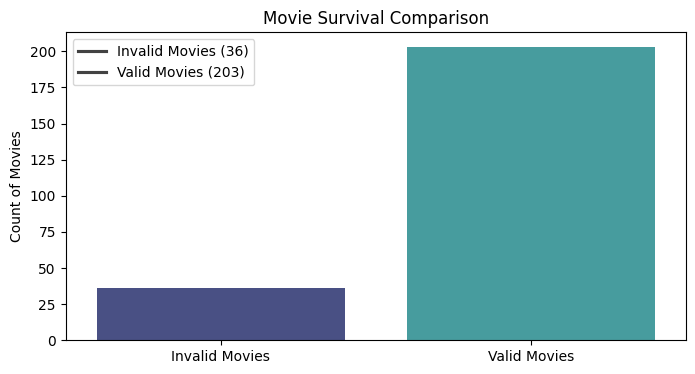

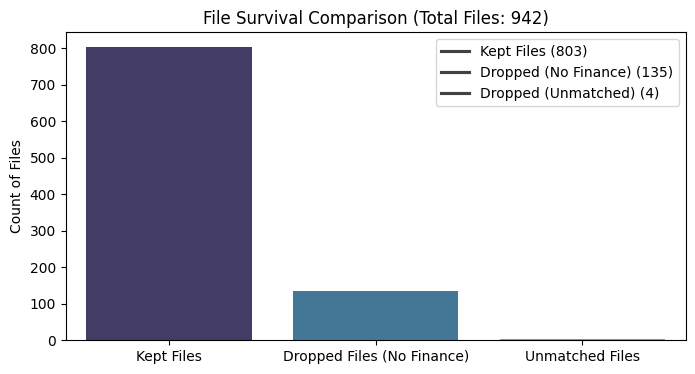

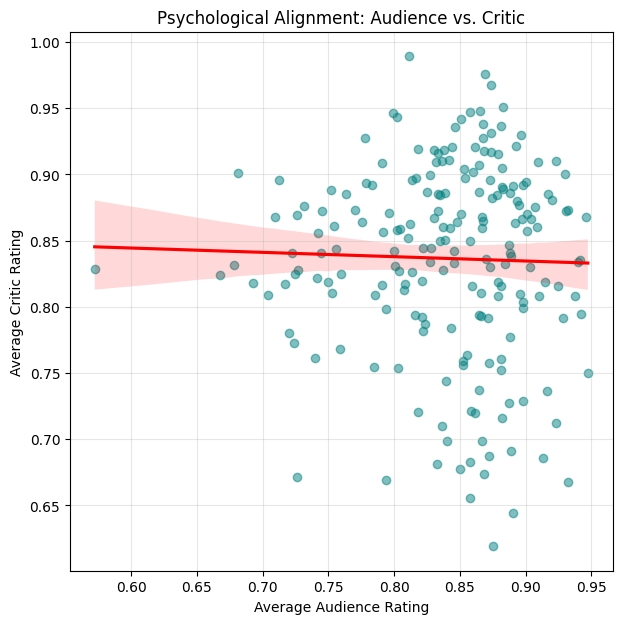

Sentiment Correlation Coefficient: -0.03


In [55]:
# execution 

# intialize and extract 
manager = MovieWorkflowManager()
full_dataset = manager.run_full_extraction()

# run eda 
manager.run_eda_visuals(full_dataset)

# generate trials
# trial_a, trial_b = manager.generate_trials(full_dataset)
# winning_trial_name = manager.compare_trials_initially(trial_a, trial_b)